In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv('games.csv')

In [3]:
df.head()

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


In [4]:
df.columns = df.columns.str.lower()

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16446 non-null  float64
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       10014 non-null  object 
 10  rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


In [6]:
df['year_of_release'] = df['year_of_release'].fillna(0)

In [7]:
df['year_of_release'].unique()

array([2006., 1985., 2008., 2009., 1996., 1989., 1984., 2005., 1999.,
       2007., 2010., 2013., 2004., 1990., 1988., 2002., 2001., 2011.,
       1998., 2015., 2012., 2014., 1992., 1997., 1993., 1994., 1982.,
       2016., 2003., 1986., 2000.,    0., 1995., 1991., 1981., 1987.,
       1980., 1983.])

In [8]:
df['year_of_release'] = df['year_of_release'].astype('int')

In [9]:
df['rating'].unique()

array(['E', nan, 'M', 'T', 'E10+', 'K-A', 'AO', 'EC', 'RP'], dtype=object)

In [10]:
df.insert(8, 'total_sales', df['na_sales']+df['eu_sales']+df['jp_sales']+df['other_sales'])

In [11]:
df.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,total_sales,critic_score,user_score,rating
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,82.54,76.0,8,E
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,35.52,82.0,8.3,E
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,32.77,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,31.38,NaN,NaN,NaN


In [12]:
pivot_by_year = df[df['year_of_release']>0].pivot_table(index='year_of_release', values='name', aggfunc='count')

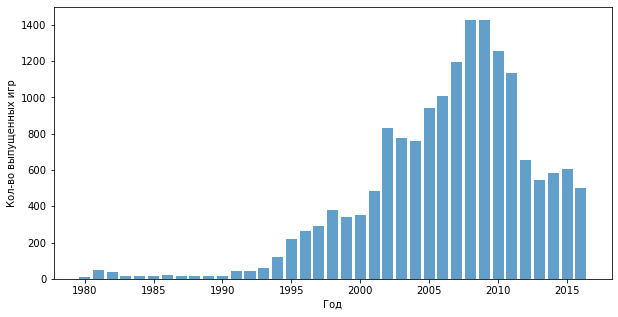

In [13]:
x=pivot_by_year.index
y=pivot_by_year['name']

plt.figure(figsize=(10,5))

plt.xlabel('Год')
plt.ylabel('Кол-во выпущенных игр')

plt.bar(x, y, alpha=0.7)
plt.show()

In [14]:
pivot_by_platform = df.pivot_table(index='platform', 
                                   values='total_sales', 
                                   aggfunc='sum').sort_values(by='total_sales', 
                                                                ascending=True).tail(10)

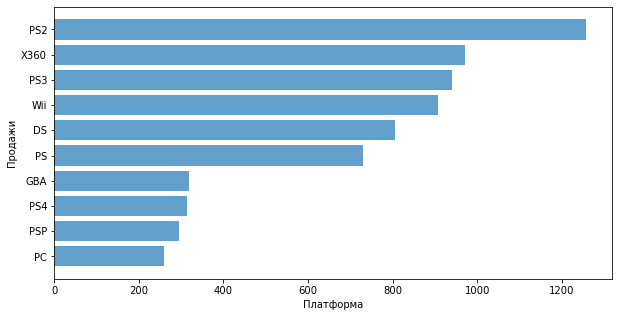

In [15]:
x=pivot_by_platform.index
y=pivot_by_platform['total_sales']

plt.figure(figsize=(10,5))

plt.xlabel('Платформа')
plt.ylabel('Продажи')

plt.barh(x, y, alpha=0.7)
plt.show()

In [16]:
top_platforms = list(pivot_by_platform.index)
top_platform_sales = df.query('platform in @top_platforms & year_of_release >0')

In [17]:
each_platform_pivot_by_year = top_platform_sales.pivot_table(index='year_of_release', 
                                                             values='total_sales', 
                                                             columns = 'platform',
                                                             aggfunc='sum')

In [18]:
each_platform_pivot_by_year = each_platform_pivot_by_year.fillna(0)

In [19]:
each_platform_pivot_by_year

platform,DS,GBA,PC,PS,PS2,PS3,PS4,PSP,Wii,X360
year_of_release,,,,,,,,,,
1985,0.02,0.00,0.04,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1988,0.00,0.00,0.03,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1992,0.00,0.00,3.03,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1994,0.00,0.00,12.87,6.03,0.00,0.00,0.00,0.00,0.00,0.00
1995,0.00,0.00,4.22,35.96,0.00,0.00,0.00,0.00,0.00,0.00
1996,0.00,0.00,10.58,94.70,0.00,0.00,0.00,0.00,0.00,0.00
1997,0.00,0.00,11.27,136.17,0.00,0.00,0.00,0.00,0.00,0.00
1998,0.00,0.00,3.26,169.49,0.00,0.00,0.00,0.00,0.00,0.00
1999,0.00,0.00,4.74,144.53,0.00,0.00,0.00,0.00,0.00,0.00


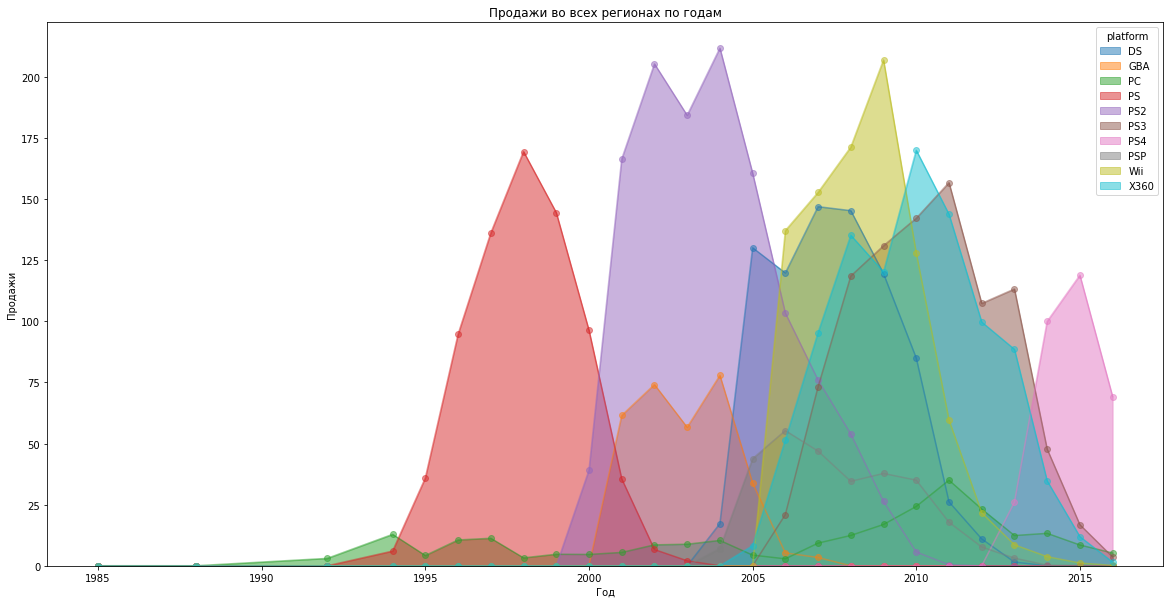

In [20]:
each_platform_pivot_by_year.plot.area(figsize=(20,10),
                                      xlabel = 'Год',
                                      ylabel = 'Продажи',
                                      title = 'Продажи во всех регионах по годам',
                                      style = 'o-',
                                      stacked=False);

In [21]:
each_platform_pivot_by_year_percentage = pd.DataFrame()

for platform in each_platform_pivot_by_year.columns:
    each_platform_pivot_by_year_percentage[platform] = \
    each_platform_pivot_by_year[platform] / each_platform_pivot_by_year[platform].sum()

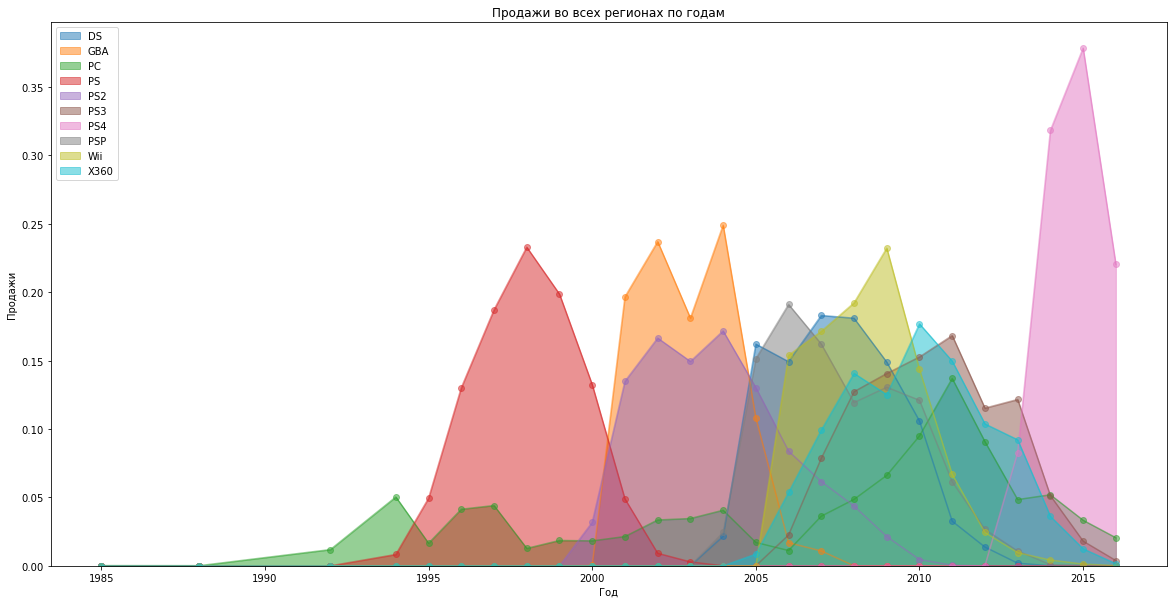

In [22]:
each_platform_pivot_by_year_percentage.plot.area(figsize=(20,10),
                                      xlabel = 'Год',
                                      ylabel = 'Продажи',
                                      title = 'Продажи во всех регионах по годам',
                                      style = 'o-',
                                      stacked=False);

In [23]:
platform_lifetime = pd.DataFrame(index=['min_year', 'mean_year', 'max_year', 'lifetime'])

for platform in each_platform_pivot_by_year_percentage.columns:
    mean_year = 0
    mean_year2 = 0

    for year in each_platform_pivot_by_year_percentage.index:    
        mean_year += year * each_platform_pivot_by_year_percentage[platform][year]
        mean_year2 += year * year * each_platform_pivot_by_year_percentage[platform][year]
        
    mean2_year = mean_year ** 2
    var_year = mean_year2 - mean2_year
    std_year = np.sqrt(var_year)

    min_year = mean_year - 3*std_year
    max_year = mean_year + 3*std_year
    lifetime = max_year - min_year

    platform_lifetime[platform] = [min_year, mean_year, max_year, lifetime]

platform_lifetime = np.transpose(platform_lifetime)
platform_lifetime = platform_lifetime.sort_values(by='lifetime')

In [24]:
each_platform_pivot_by_year

platform,DS,GBA,PC,PS,PS2,PS3,PS4,PSP,Wii,X360
year_of_release,,,,,,,,,,
1985,0.02,0.00,0.04,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1988,0.00,0.00,0.03,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1992,0.00,0.00,3.03,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1994,0.00,0.00,12.87,6.03,0.00,0.00,0.00,0.00,0.00,0.00
1995,0.00,0.00,4.22,35.96,0.00,0.00,0.00,0.00,0.00,0.00
1996,0.00,0.00,10.58,94.70,0.00,0.00,0.00,0.00,0.00,0.00
1997,0.00,0.00,11.27,136.17,0.00,0.00,0.00,0.00,0.00,0.00
1998,0.00,0.00,3.26,169.49,0.00,0.00,0.00,0.00,0.00,0.00
1999,0.00,0.00,4.74,144.53,0.00,0.00,0.00,0.00,0.00,0.00


In [25]:
platform_lifetime.style.format('{:.2f}')

,min_year,mean_year,max_year,lifetime
PS4,2012.05,2014.74,2017.42,5.37
GBA,1998.66,2002.93,2007.20,8.54
PS,1993.13,1998.03,2002.93,9.81
Wii,2003.34,2008.42,2013.51,10.17
DS,2001.90,2007.47,2013.04,11.14
PSP,2001.30,2007.63,2013.96,12.67
PS3,2003.84,2010.36,2016.88,13.04
PS2,1997.12,2003.78,2010.44,13.32
X360,2003.19,2009.89,2016.58,13.39
PC,1987.12,2006.65,2026.18,39.06


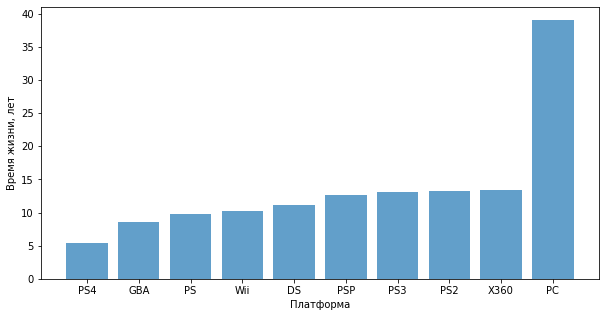

In [26]:
x=platform_lifetime.index
y=platform_lifetime['lifetime']

plt.figure(figsize=(10,5))

plt.xlabel('Платформа')
plt.ylabel('Время жизни, лет')

plt.bar(x, y, alpha=0.7)
plt.show()

In [27]:
mean_lifetime = round(platform_lifetime[platform_lifetime.index != 'PC']['lifetime'].mean(),2)

In [28]:
mean_lifetime

10.83

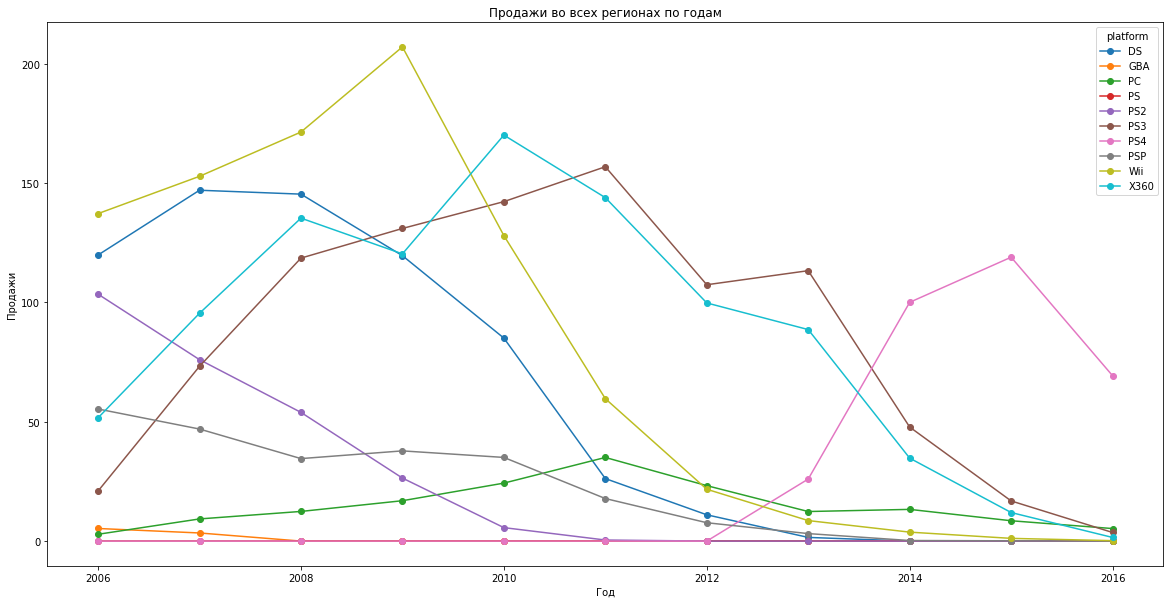

In [33]:
each_platform_pivot_by_year.query('year_of_release > (year_of_release.max()-@mean_lifetime)')\
.plot(figsize=(20,10),
      xlabel = 'Год',
      ylabel = 'Продажи',
      title = 'Продажи во всех регионах по годам',
      style = 'o-',
      stacked=False);

In [35]:
each_platform_pivot_by_year['PC']

year_of_release
1985     0.04
1988     0.03
1992     3.03
1994    12.87
1995     4.22
1996    10.58
1997    11.27
1998     3.26
1999     4.74
2000     4.66
2001     5.47
2002     8.57
2003     8.84
2004    10.39
2005     4.37
2006     2.85
2007     9.28
2008    12.42
2009    16.91
2010    24.28
2011    35.03
2012    23.22
2013    12.38
2014    13.28
2015     8.52
2016     5.25
Name: PC, dtype: float64

In [40]:
pivot_by_platform

,total_sales
platform,
PC,259.52
PSP,294.05
PS4,314.14
GBA,317.85
PS,730.86
DS,806.12
Wii,907.51
PS3,939.65
X360,971.42


<AxesSubplot:>

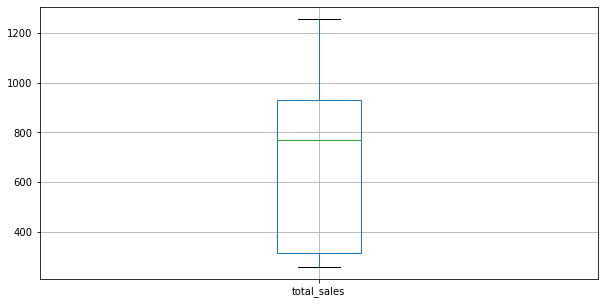

In [39]:
pivot_by_platform.boxplot(figsize = (10,5))